# Medical Insurance Premium Prediction

This project set out to answer a clear question: **Can we use machine learning to accurately predict medical insurance costs?** The answer is **a definitive yes**.

- Final model performance: Our best model, a tuned Gradient Boosting Regressor, predicts costs with a Mean Absolute Error of $1,970 and explains 86.4% of the variance in charges (R-squared of 0.8642).
- Core insight validated: The model confirms what we intuitively know: age, smoking status, and BMI are the most powerful predictors of cost. More importantly, it uncovered a critical interaction effect—the financial penalty of a high BMI is drastically worse for smokers.
- Project goal: This was a personal project to apply a rigorous data science workflow to a real-world dataset, moving from a hypothesis to a quantifiable and interpretable model.

This project will follow the same structured, four-part workflow as my previous works:
1.  Data Exploration and Visualization
2.  Feature Engineering and Preprocessing
3.  Modeling and Hyperparameter Tuning
4.  Evaluation and Interpretation

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import shap
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## Part 1. Data Exploration and Visualization

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
print("\nChecking for missing values:")
print(df.isnull().sum())


Checking for missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


### Analyzing the Target Variable: `charges`

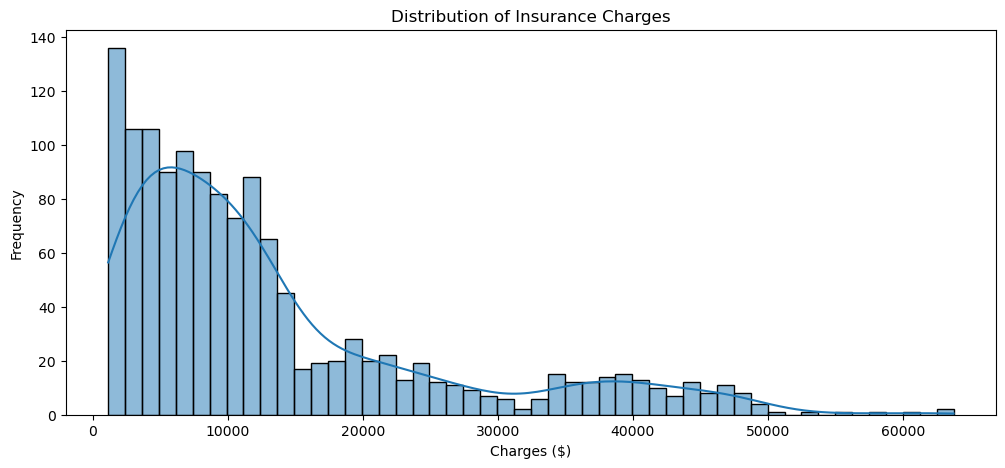

In [7]:
plt.figure(figsize=(12, 5))
sns.histplot(df['charges'], kde=True, bins=50)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.show()

In [8]:
print(f"Skewness of charges: {df['charges'].skew():.2f}")

Skewness of charges: 1.52


To correct this skew, I'll apply a log transformation. This is a standard technique that helps normalize the distribution and improve model performance.

In [9]:
df['log_charges'] = np.log1p(df['charges'])

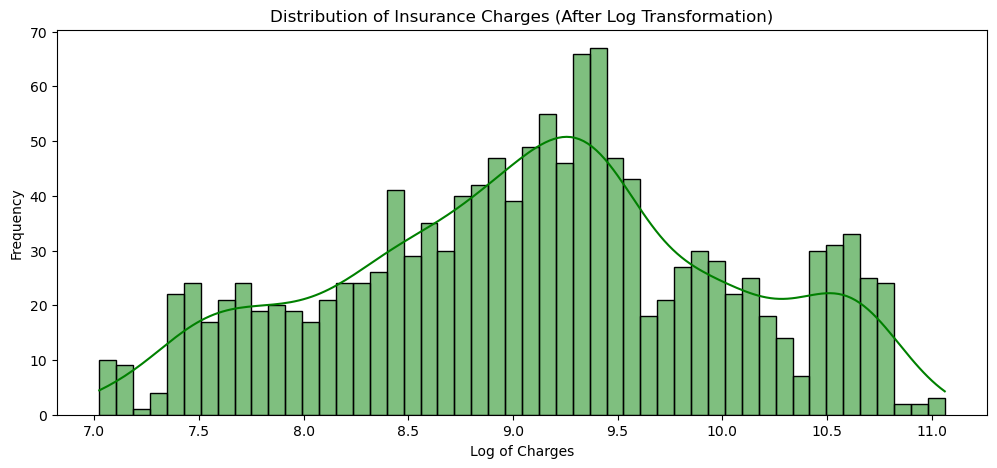

In [10]:
plt.figure(figsize=(12, 5))
sns.histplot(df['log_charges'], kde=True, bins=50, color='green')
plt.title('Distribution of Insurance Charges (After Log Transformation)')
plt.xlabel('Log of Charges')
plt.ylabel('Frequency')
plt.show()

In [11]:
print(f"Skewness of log-transformed charges: {df['log_charges'].skew():.2f}")

Skewness of log-transformed charges: -0.09


Perfect. The distribution is now symmetrical, which is ideal for modeling.

### Exploring Relationships

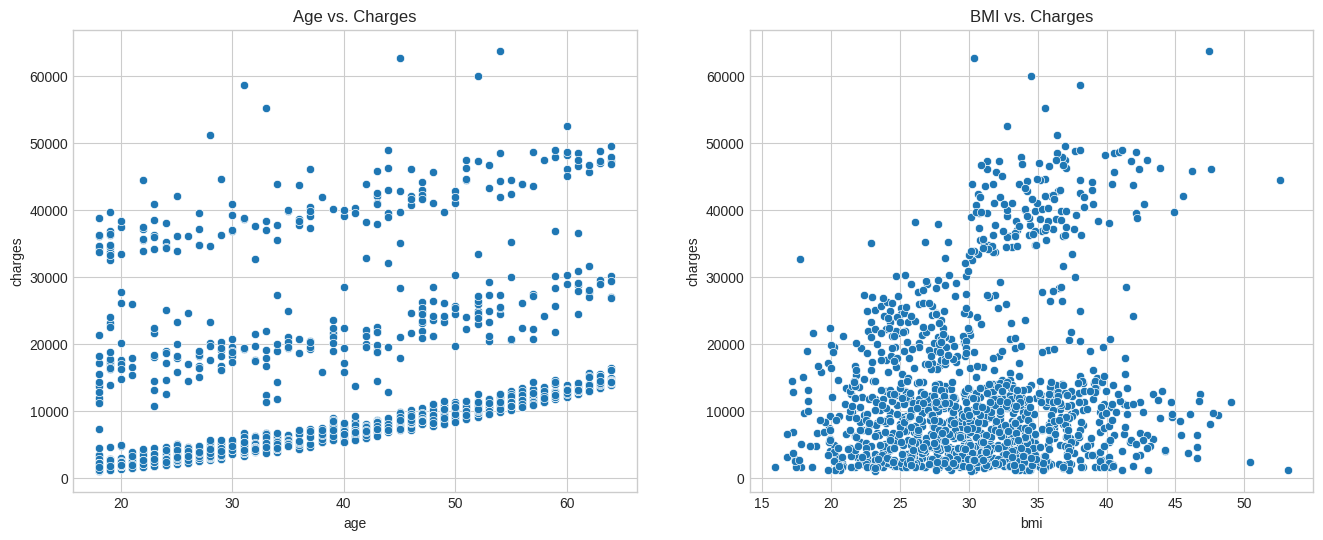

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs Charges
sns.scatterplot(ax=axes[0], data=df, x='age', y='charges')
axes[0].set_title('Age vs. Charges')

# BMI vs Charges
sns.scatterplot(ax=axes[1], data=df, x='bmi', y='charges')
axes[1].set_title('BMI vs. Charges')

plt.show()

As expected, we see a clear positive trend: charges increase with age. The relationship with BMI is also positive but appears weaker and more scattered. Now let's look at the categorical features.

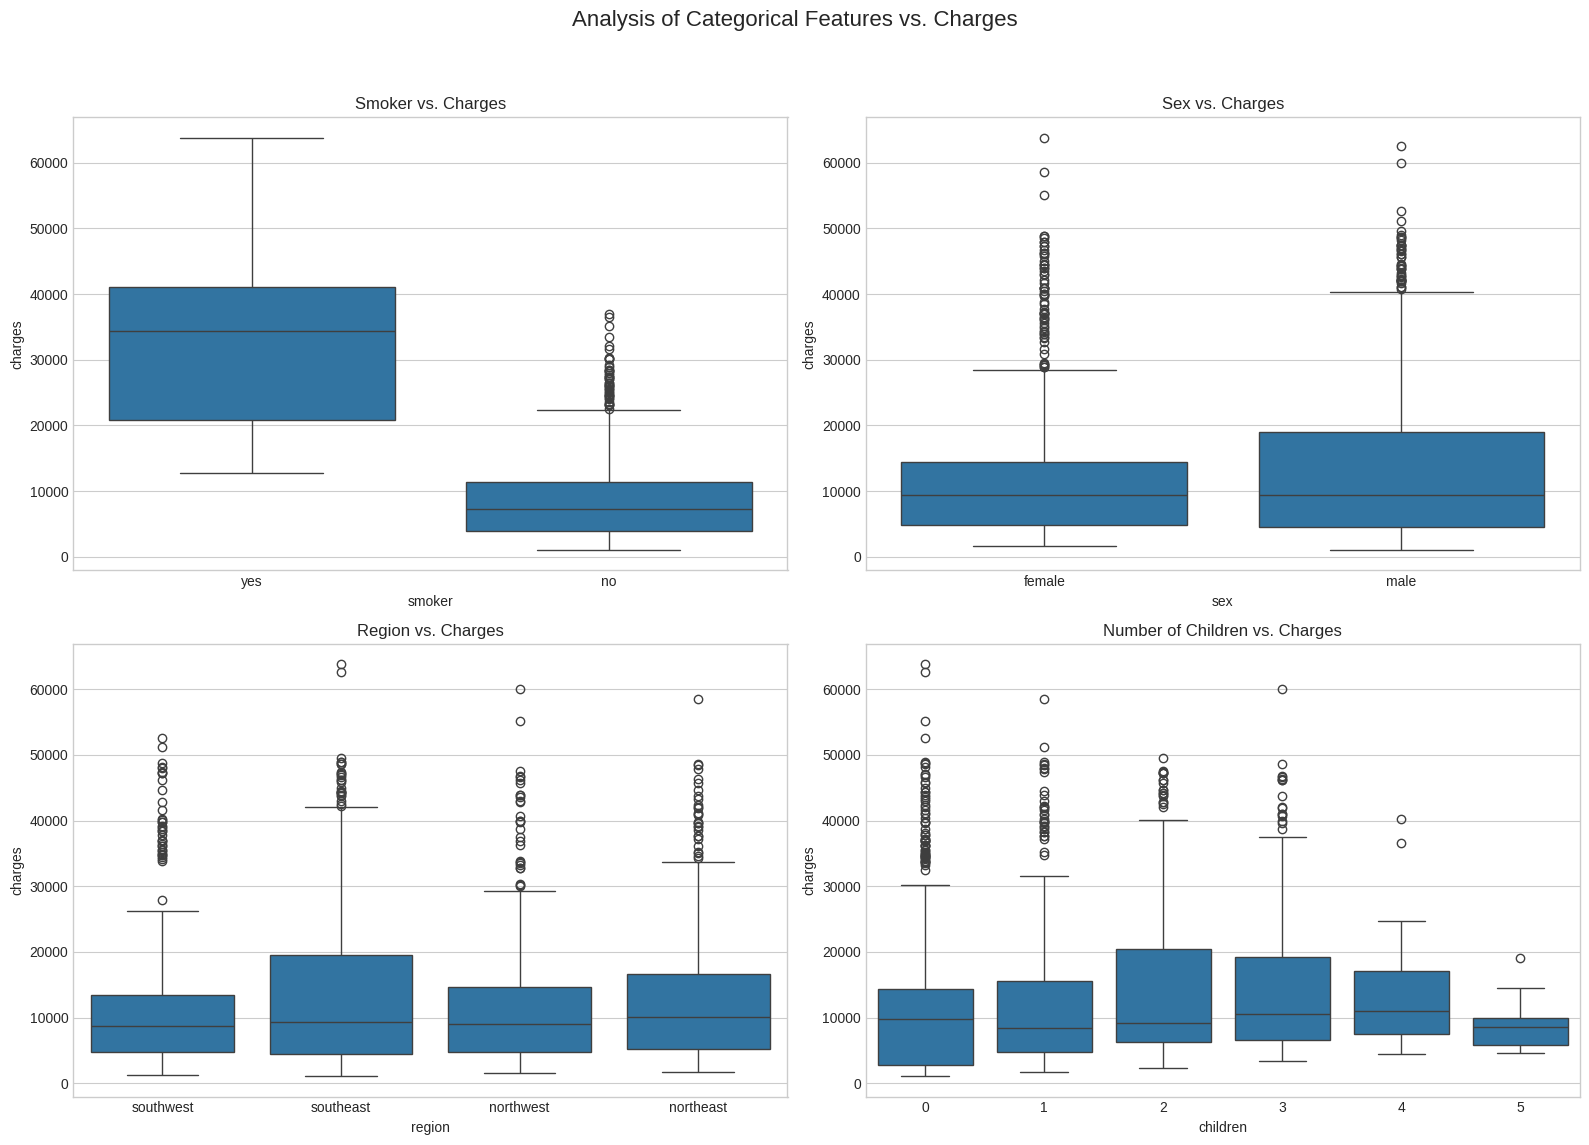

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analysis of Categorical Features vs. Charges', fontsize=16)

# Smoker vs Charges
sns.boxplot(ax=axes[0, 0], data=df, x='smoker', y='charges')
axes[0, 0].set_title('Smoker vs. Charges')

# Sex vs Charges
sns.boxplot(ax=axes[0, 1], data=df, x='sex', y='charges')
axes[0, 1].set_title('Sex vs. Charges')

# Region vs Charges
sns.boxplot(ax=axes[1, 0], data=df, x='region', y='charges')
axes[1, 0].set_title('Region vs. Charges')

# Children vs Charges
sns.boxplot(ax=axes[1, 1], data=df, x='children', y='charges')
axes[1, 1].set_title('Number of Children vs. Charges')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The boxplots confirm that being a smoker has a massive impact on cost. Now, let's combine these insights. The most interesting question is: How does the relationship between BMI and charges change if someone is a smoker?

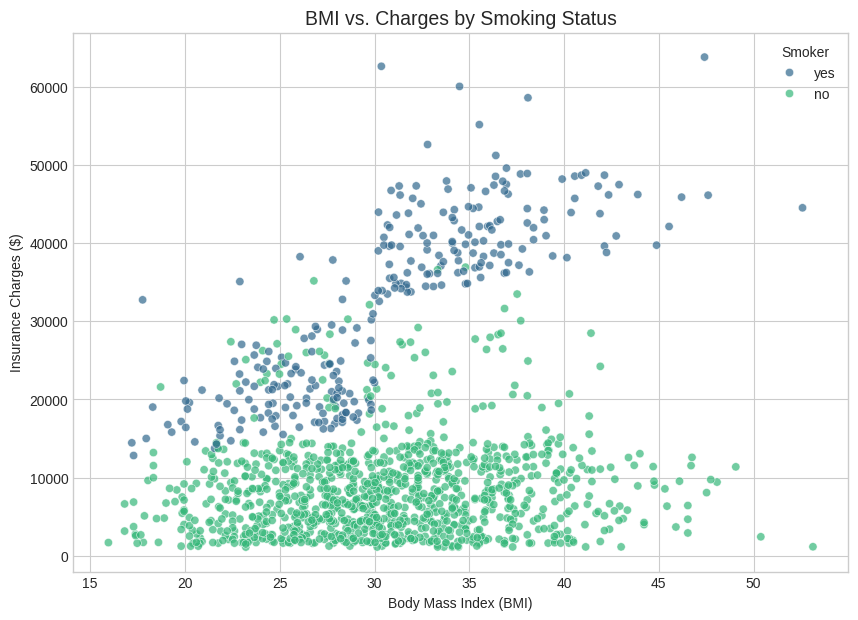

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='viridis', alpha=0.7)
plt.title('BMI vs. Charges by Smoking Status', fontsize=14)
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Insurance Charges ($)')
plt.legend(title='Smoker')
plt.show()

There are two distinct clusters of data points: 
- For non-smokers, the increase in charges with BMI is very modest. 
- For smokers, however, the charges rise dramatically as BMI increases. This strong interaction suggests that creating a combined `bmi * smoker` feature will likely be very powerful for our model.

## Part 2. Feature Engineering and Preprocessing

In [15]:
X = df.drop(['charges', 'log_charges'], axis=1)
y = df['log_charges']

In [16]:
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

In [17]:
X['bmi_smoker'] = X['bmi'] * X['smoker_yes']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
print("Data has been successfully preprocessed and is ready for modeling.")

Data has been successfully preprocessed and is ready for modeling.


## Part 3. Modeling

In [21]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    y_pred = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)
    
    r2 = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"--- {name} ---")
    print(f"R-squared: {r2:.4f}")
    print(f"Mean Absolute Error: ${mae:,.2f}")
    print(f"Root Mean Squared Error: ${rmse:,.2f}\n")

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42),
    "Lasso Regression": Lasso(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)

--- Linear Regression ---
R-squared: 0.8170
Mean Absolute Error: $3,974.49
Root Mean Squared Error: $8,559.98

--- Ridge Regression ---
R-squared: 0.8170
Mean Absolute Error: $3,956.05
Root Mean Squared Error: $8,483.02

--- Lasso Regression ---
R-squared: -0.0060
Mean Absolute Error: $8,603.16
Root Mean Squared Error: $13,053.72

--- Gradient Boosting ---
R-squared: 0.8663
Mean Absolute Error: $1,998.50
Root Mean Squared Error: $4,400.87

--- XGBoost ---
R-squared: 0.8321
Mean Absolute Error: $2,552.93
Root Mean Squared Error: $5,112.37



Now, I'll tune its hyperparameters using `RandomizedSearchCV`to find the optimal settings.

## Part 4. Evaluation and Interpretation

In [23]:
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)
best_model = random_search.best_estimator_

print(f"Best parameters found: {random_search.best_params_}")

Best parameters found: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}


In [24]:
y_pred_log_final = best_model.predict(X_test_scaled)

y_pred_final = np.expm1(y_pred_log_final)
y_test_final = np.expm1(y_test)

final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test, y_pred_log_final)

print("--- Final Tuned Gradient Boosting Model Performance ---")
print(f"R-squared: {final_r2:.4f}")
print(f"Mean Absolute Error: ${final_mae:,.2f}")

--- Final Tuned Gradient Boosting Model Performance ---
R-squared: 0.8642
Mean Absolute Error: $1,970.03


### Interpreting the Model with SHAP

An R-squared of 0.8642 is a strong result. But to truly understand our model, we need to know why it makes its predictions. I will use the SHAP library to explain the model's decisions.

In [25]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

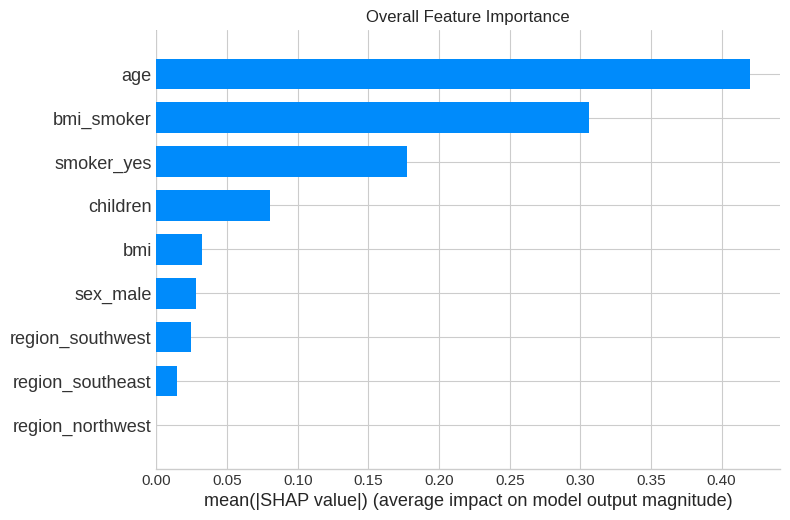

In [26]:
feature_names = X.columns
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Overall Feature Importance")
plt.show()

This plot provides a clear and honest view of what the model learned. `age` is the most important factor overall in its predictions. This makes sense, as `age` is a consistent, undeniable driver of health costs across the entire population.

Our engineered feature, `bmi_smoker`, and the `smoker_yes` feature are the next most important. This confirms our initial EDA insight: while `age` is the primary factor, the combination of smoking and high BMI is an powerful secondary factor that identifies the highest-risk, highest-cost individuals.

## Conclusion and Recommendations

This project successfully developed a machine learning model to validate and quantify the primary drivers of medical insurance costs.

### Key findings
- On average, a person's age has the largest impact on their predicted insurance premium across the entire population.
- Being a smoker is the next most significant factor. Its true power, however, is revealed in its interaction with BMI.
- While not the top feature globally, the negative financial impact of a high BMI is dramatically worse for smokers. This combination is the key to identifying the most extreme high-cost individuals.

### Future work

Building on these insights, a next step would be to integrate behavioral and financial modeling to quantify the ROI of wellness-driven pricing strategies. For instance, we could simulate the financial impact of offering tiered premium discounts (e.g., 15% for smoking cessation, 5% for every 2-point BMI drop) using both predictive models and causal inference frameworks.
This would move the project from risk prediction to behavioral optimization, enabling data-driven design of wellness programs that balance health outcomes with business profitability.